<a href="https://colab.research.google.com/github/madaam99/EnergyGermany/blob/main/SMARD_EDA_weekly.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

In [2]:
upload = files.upload()

Saving processedErzeugung to processedErzeugung
Saving processedVerbrauch to processedVerbrauch
Saving processedInstalledEnergy to processedInstalledEnergy


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
instEnergy = pd.read_csv("/content/processedInstalledEnergy")
erzeugung = pd.read_csv("/content/processedErzeugung")
verbrauch = pd.read_csv("/content/processedVerbrauch")

In [5]:
instEnergy['Datum von'] = pd.to_datetime(instEnergy['Datum von'])
instEnergy['Datum bis'] = pd.to_datetime(instEnergy['Datum bis'])

erzeugung['Datum von'] = pd.to_datetime(erzeugung['Datum von'])
erzeugung['Datum bis'] = pd.to_datetime(erzeugung['Datum bis'])

verbrauch['Datum von'] = pd.to_datetime(verbrauch['Datum von'])
verbrauch['Datum bis'] = pd.to_datetime(verbrauch['Datum bis'])

Installed Energy

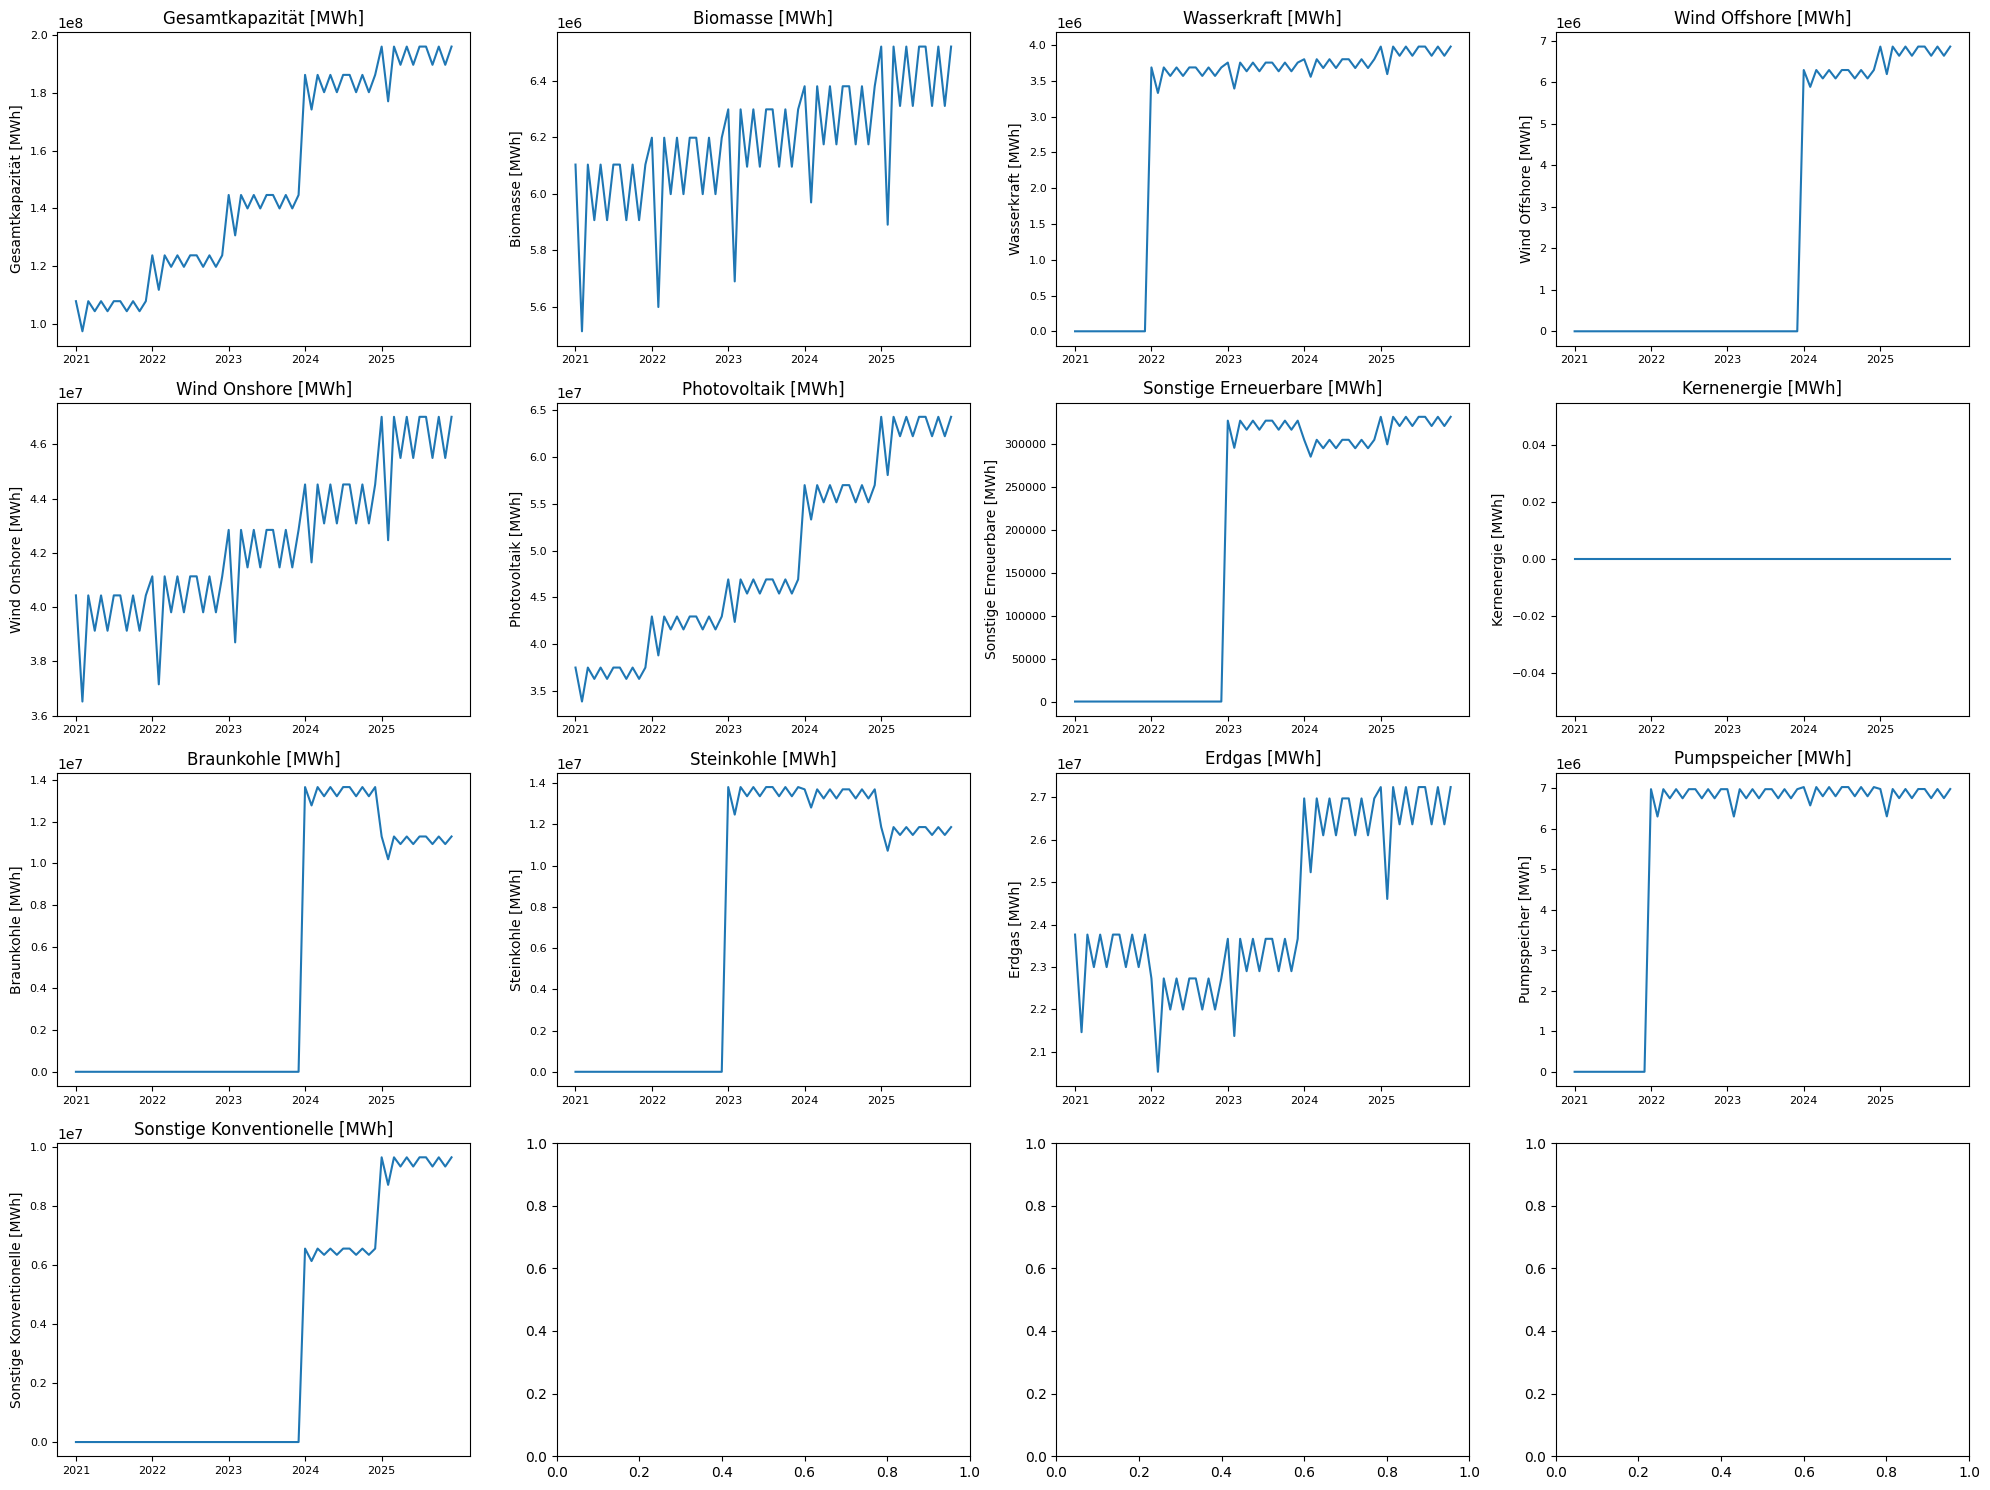

In [6]:
unique_years = instEnergy["Datum von"].dt.year.unique()
tick_locations = [pd.to_datetime(f'{year}-01-01') for year in unique_years]
tick_labels = unique_years

fig, ax = plt.subplots(4, 4, figsize=(20, 15))
ax = ax.flatten()

columns_to_plot = instEnergy.columns.drop(['Datum von', 'Datum bis'])

for i, col in enumerate(columns_to_plot):
    sns.lineplot(data=instEnergy, x="Datum von", y=col, ax=ax[i])
    ax[i].set_title(col)
    ax[i].set_xticks(tick_locations, tick_labels)
    ax[i].tick_params(axis='x', labelsize=8)
    ax[i].tick_params(axis='y', labelsize=8)
    ax[i].set_xlabel("")
plt.tight_layout()
plt.show()

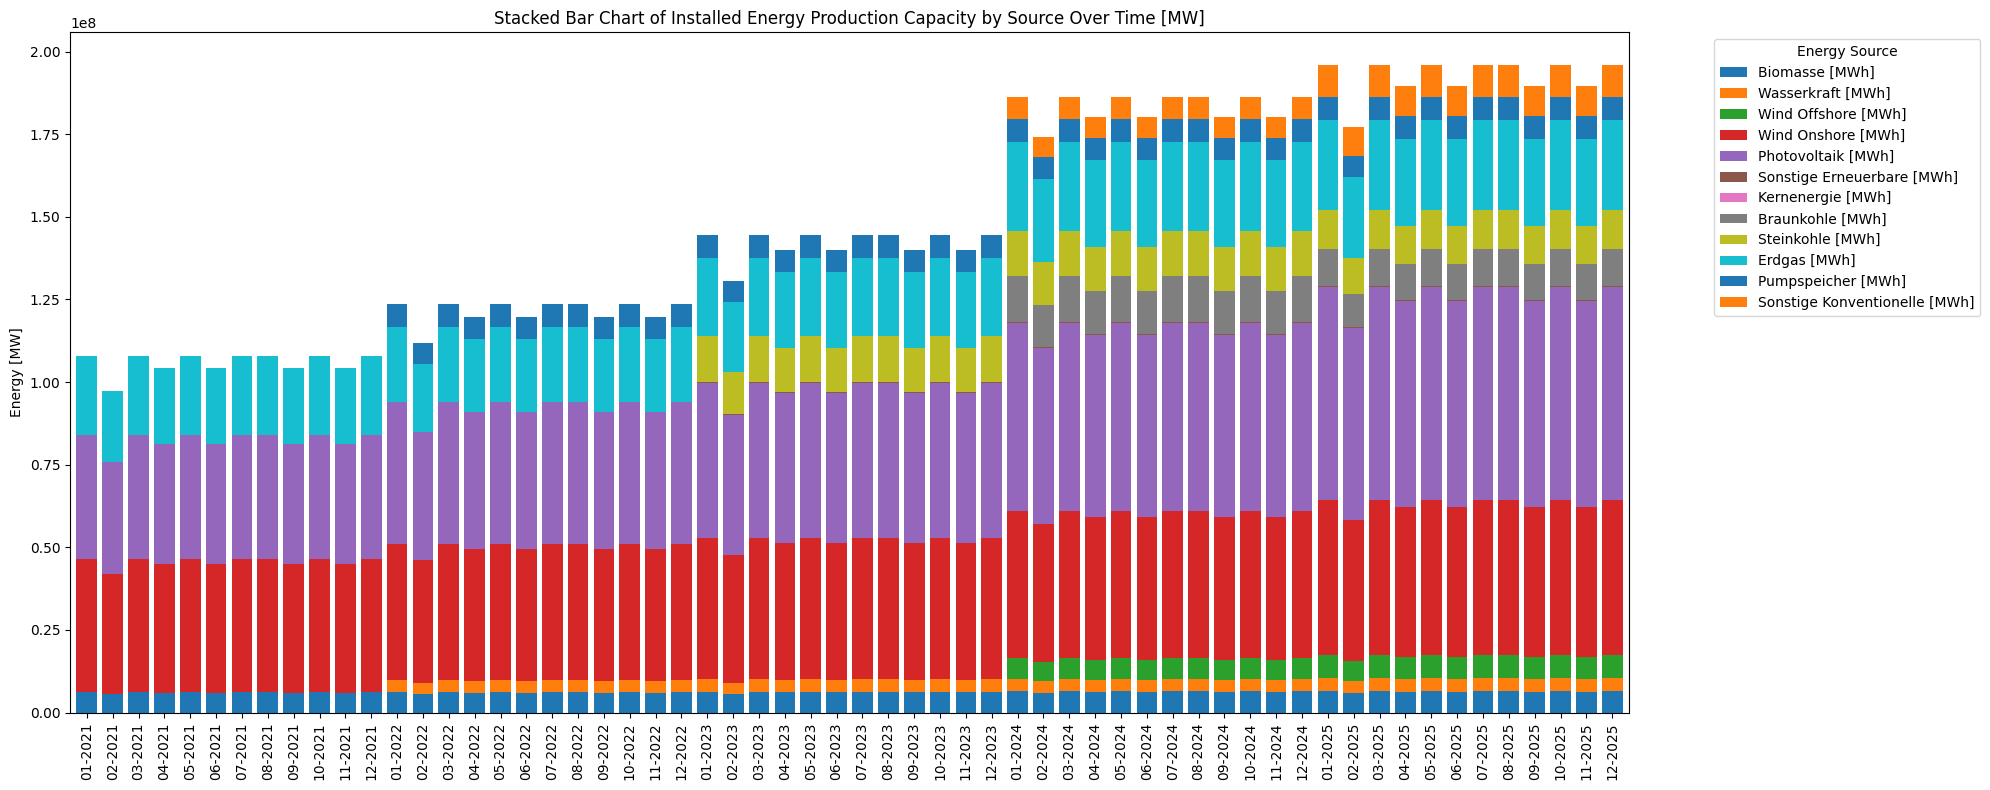

In [7]:
df_plot = instEnergy.set_index('Datum von')
columns_to_stack = df_plot.columns.drop(['Datum bis', 'Gesamtkapazität [MWh]'])

fig, ax = plt.subplots(figsize=(20, 8))
df_plot[columns_to_stack].plot(kind='bar', stacked=True, ax=ax, width=0.8)

allMonthYearLabel = df_plot.index.strftime("%m-%Y")

seenLabel = set()
allTickLocations = []
allTickLabels = []

for i, monthYear in enumerate(allMonthYearLabel):
  if monthYear not in seenLabel:
    allTickLocations.append(i)
    allTickLabels.append(monthYear)
    seenLabel.add(monthYear)

ax.set_xticks(allTickLocations, allTickLabels)
ax.set_title('Stacked Bar Chart of Installed Energy Production Capacity by Source Over Time [MW]')
ax.set_ylabel('Energy [MW]')
ax.set_xlabel('')
ax.legend(title='Energy Source', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Produced Energy

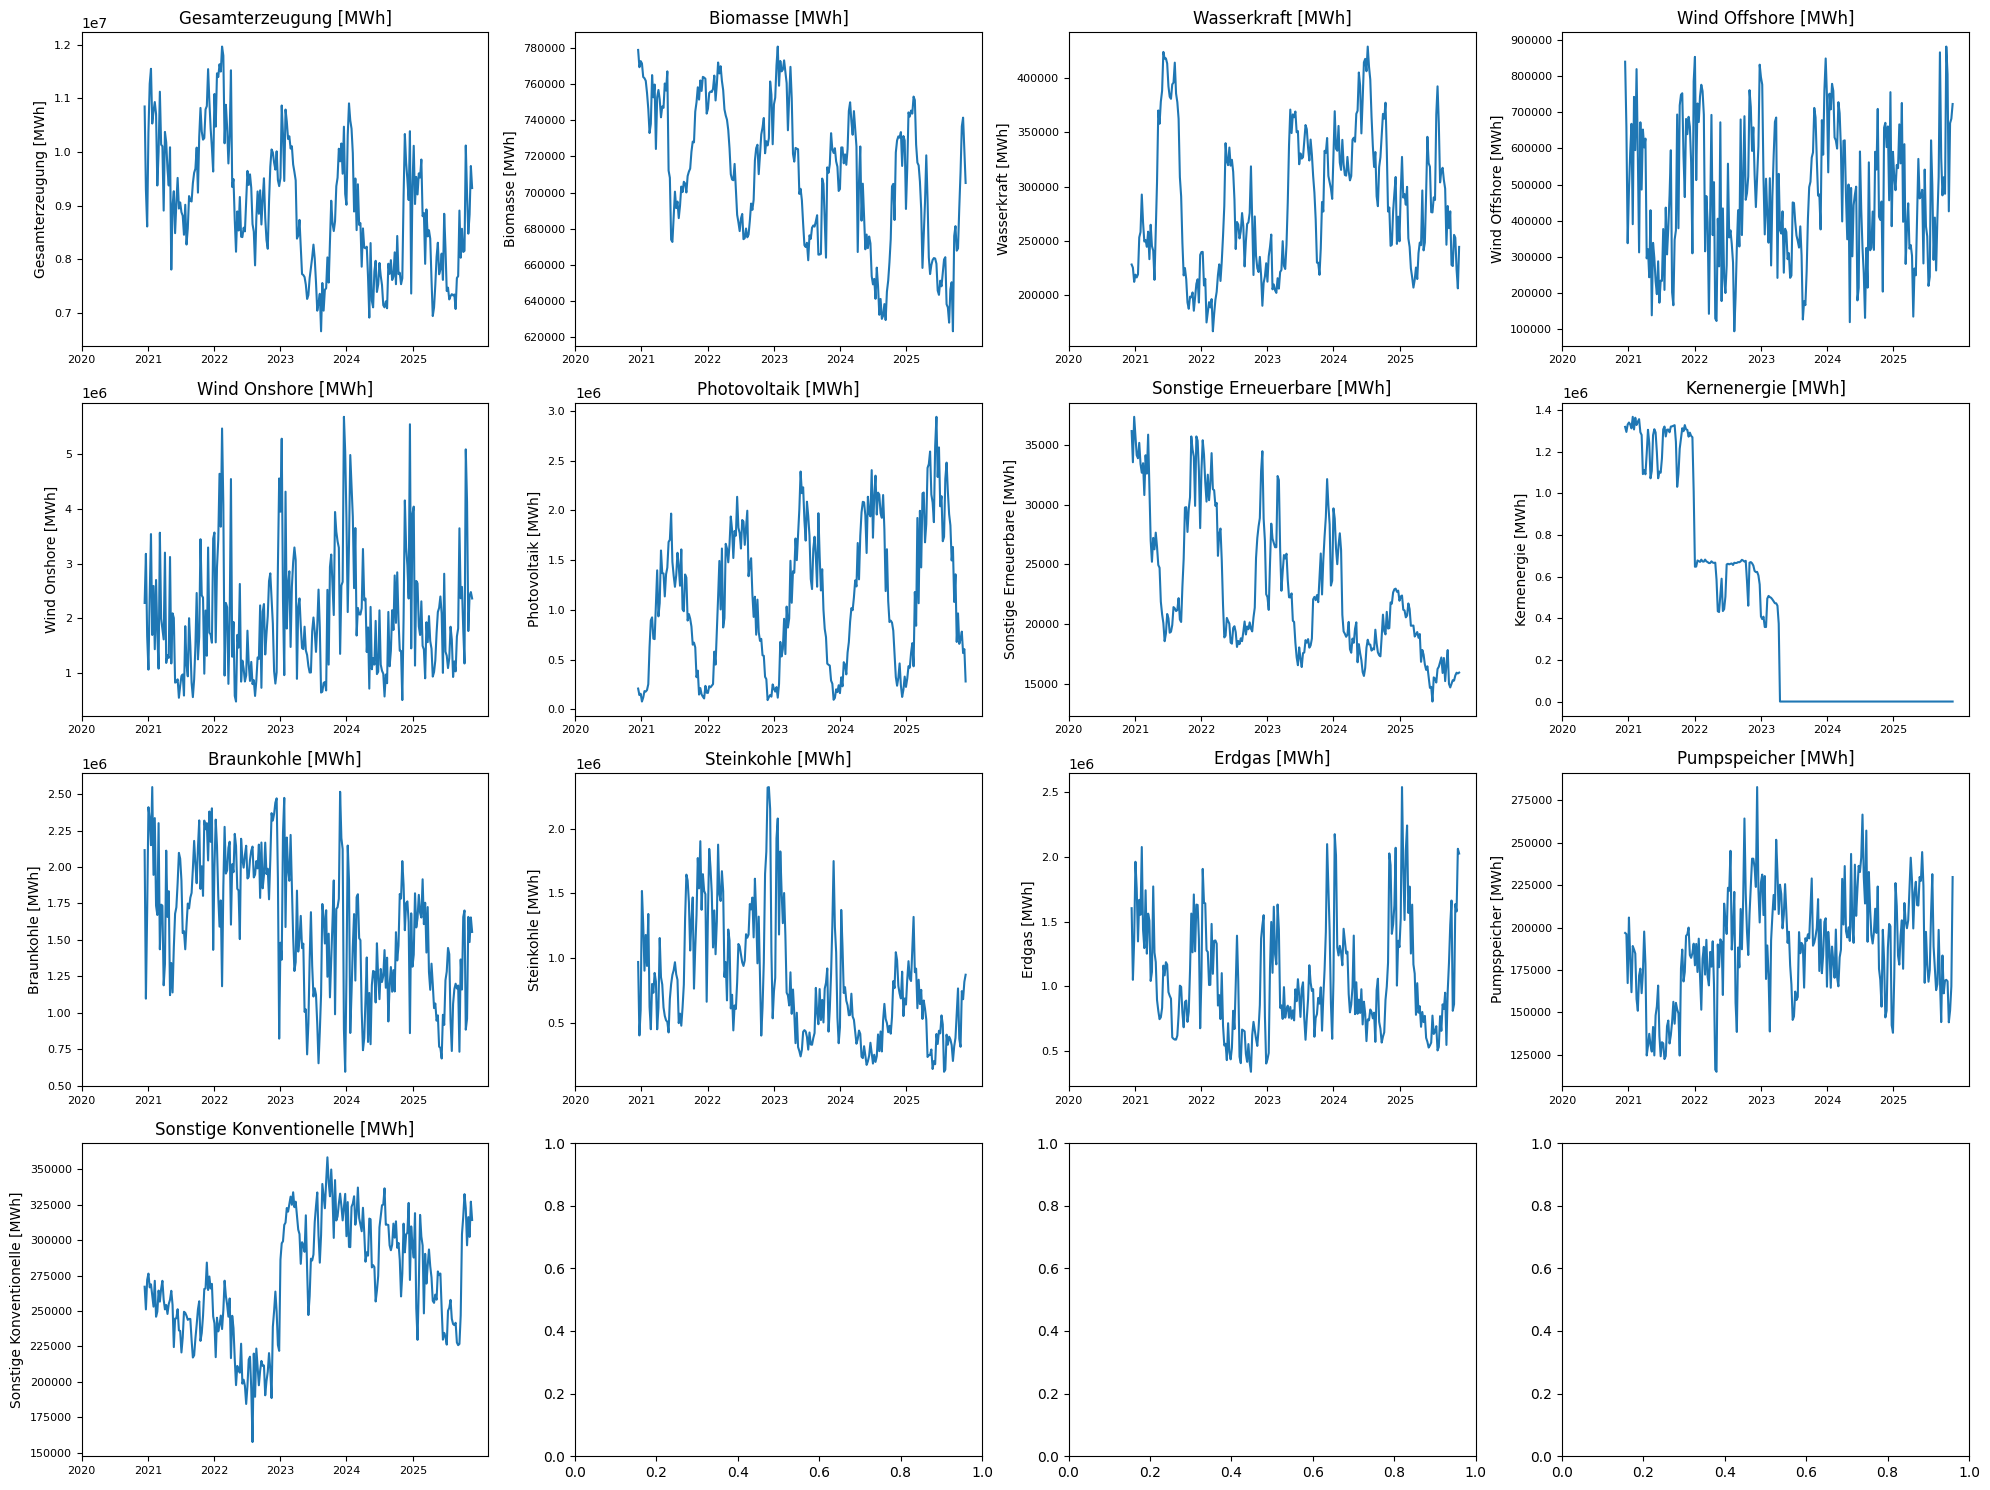

In [8]:
unique_years = erzeugung["Datum von"].dt.year.unique()
tick_locations = [pd.to_datetime(f'{year}-01-01') for year in unique_years]
tick_labels = unique_years

fig, ax = plt.subplots(4, 4, figsize=(20, 15))
ax = ax.flatten()

columns_to_plot = erzeugung.columns.drop(['Datum von', 'Datum bis'])

for i, col in enumerate(columns_to_plot):
    sns.lineplot(data=erzeugung, x="Datum von", y=col, ax=ax[i])
    ax[i].set_title(col)
    ax[i].set_xticks(tick_locations, tick_labels)
    ax[i].tick_params(axis='x', labelsize=8)
    ax[i].tick_params(axis='y', labelsize=8)
    ax[i].set_xlabel("")
plt.tight_layout()
plt.show()

In [9]:
def unique_xticklabels(all_month_year_labels, interval=1):
  unique_tick_locations = []
  unique_tick_labels = []

  seen_labels = set()
  for i, label in enumerate(all_month_year_labels):
      if label not in seen_labels:
          unique_tick_locations.append(df_plot.index[i])
          unique_tick_labels.append(label)
          seen_labels.add(label)

  interval = interval
  unique_tick_locations = unique_tick_locations[::interval]
  unique_tick_labels = unique_tick_labels[::interval]

  return unique_tick_locations, unique_tick_labels

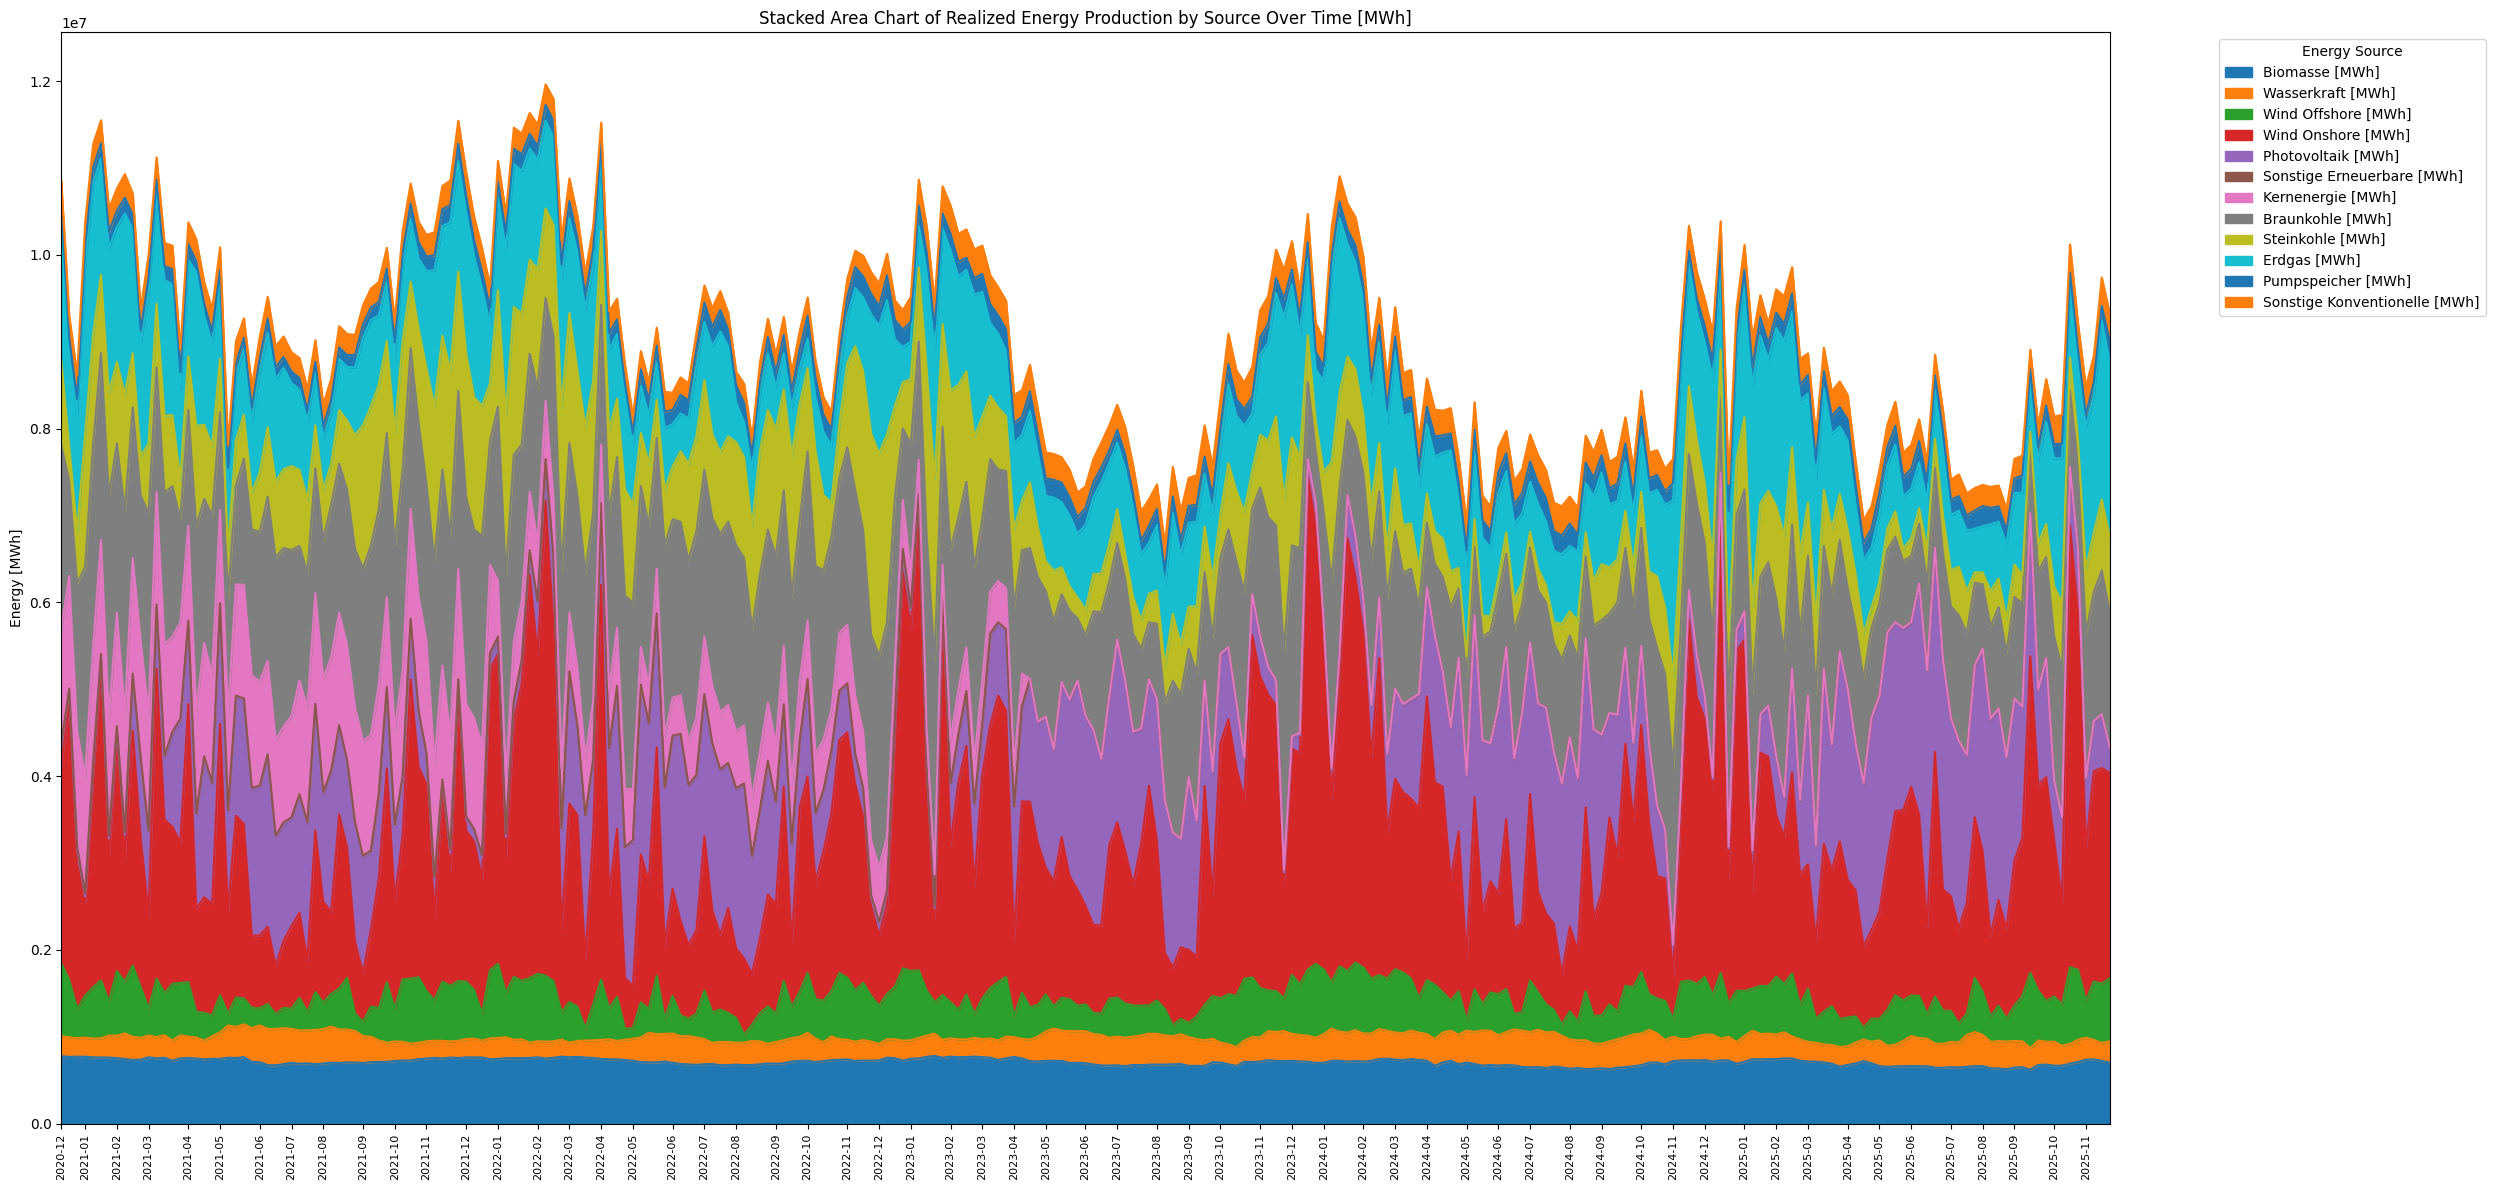

In [11]:
df_plot = erzeugung.set_index('Datum von')
columns_to_stack = df_plot.columns.drop(['Datum bis', 'Gesamterzeugung [MWh]'])

fig, ax = plt.subplots(figsize=(25, 12))
df_plot[columns_to_stack].plot(kind='area', stacked=True, ax=ax)

all_month_year_labels = df_plot.index.strftime('%Y-%m')

unique_tick_locations, unique_tick_labels = unique_xticklabels(all_month_year_labels)

ax.set_xticks(unique_tick_locations)
ax.set_xticklabels(unique_tick_labels, rotation=90, ha='center', fontsize=8)

ax.set_title('Stacked Area Chart of Realized Energy Production by Source Over Time [MWh]')
ax.set_ylabel('Energy [MWh]')
ax.set_xlabel('')
ax.legend(title='Energy Source', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Consumed Energy

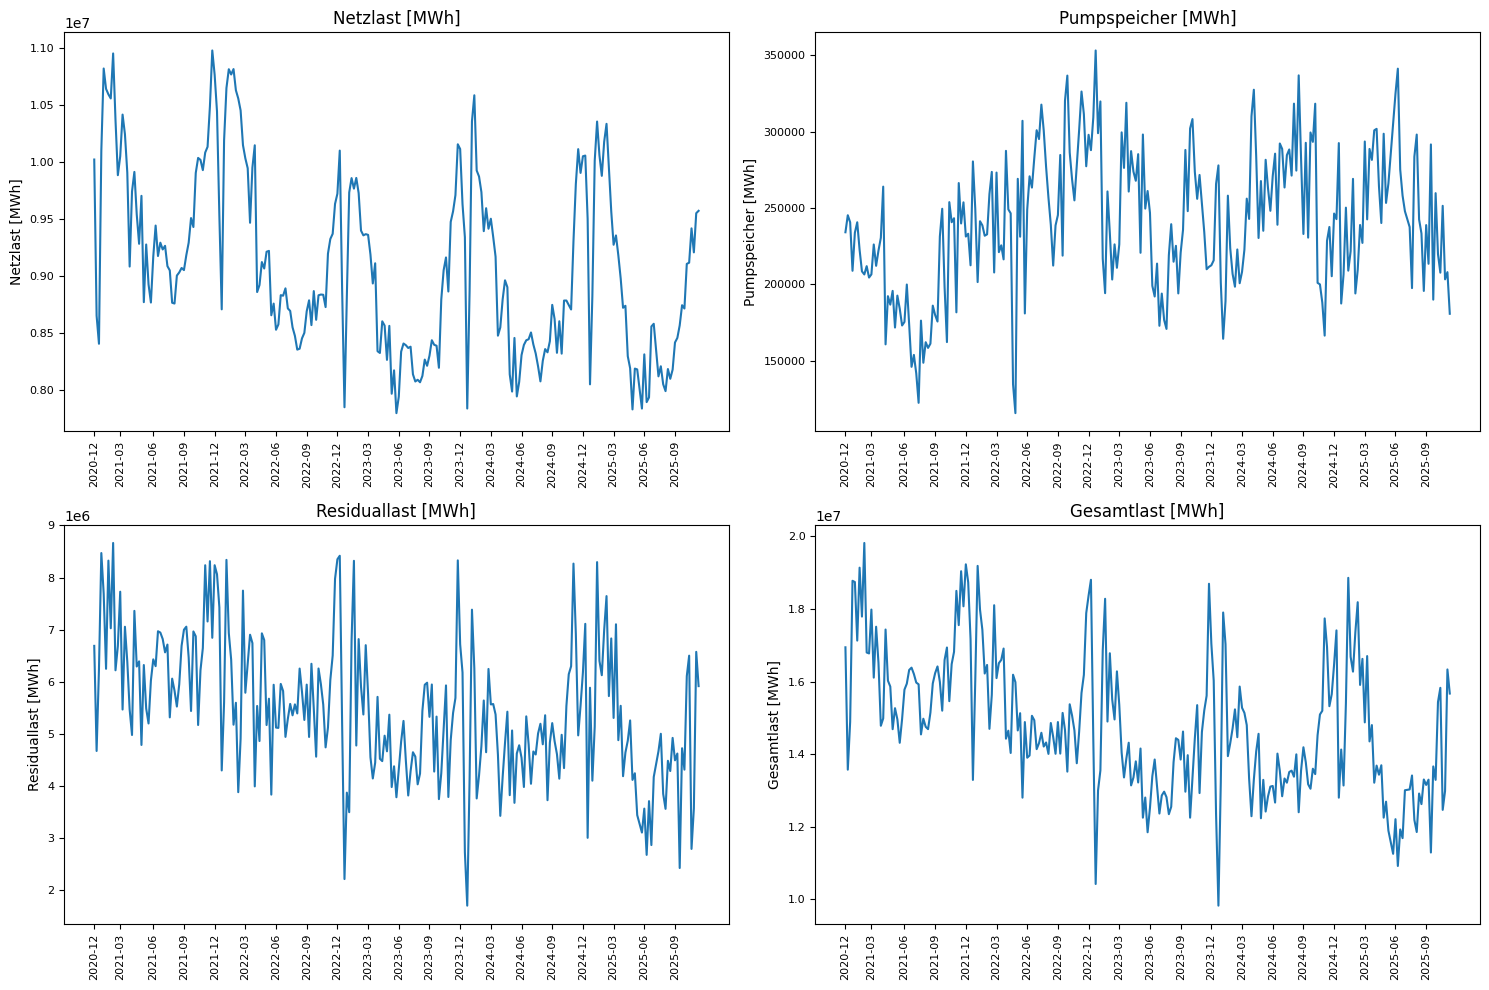

In [12]:
df_plot = verbrauch.set_index('Datum von')

plot_col = ["Netzlast [MWh]", "Pumpspeicher [MWh]", "Residuallast [MWh]", "Gesamtlast [MWh]"]

all_month_year_labels = df_plot.index.strftime('%Y-%m')

unique_tick_locations, unique_tick_labels = unique_xticklabels(all_month_year_labels, interval=3)

fig, ax = plt.subplots(2, 2, figsize=(15, 10))
ax = ax.flatten()

for i, col in enumerate(plot_col):
    sns.lineplot(data=verbrauch, x="Datum von", y=col, ax=ax[i])
    ax[i].set_title(col)
    ax[i].set_xticks(unique_tick_locations, unique_tick_labels)
    ax[i].tick_params(axis='x', labelsize=8, rotation=90)
    ax[i].tick_params(axis='y', labelsize=8)
    ax[i].set_xlabel("")
plt.tight_layout()
plt.show()

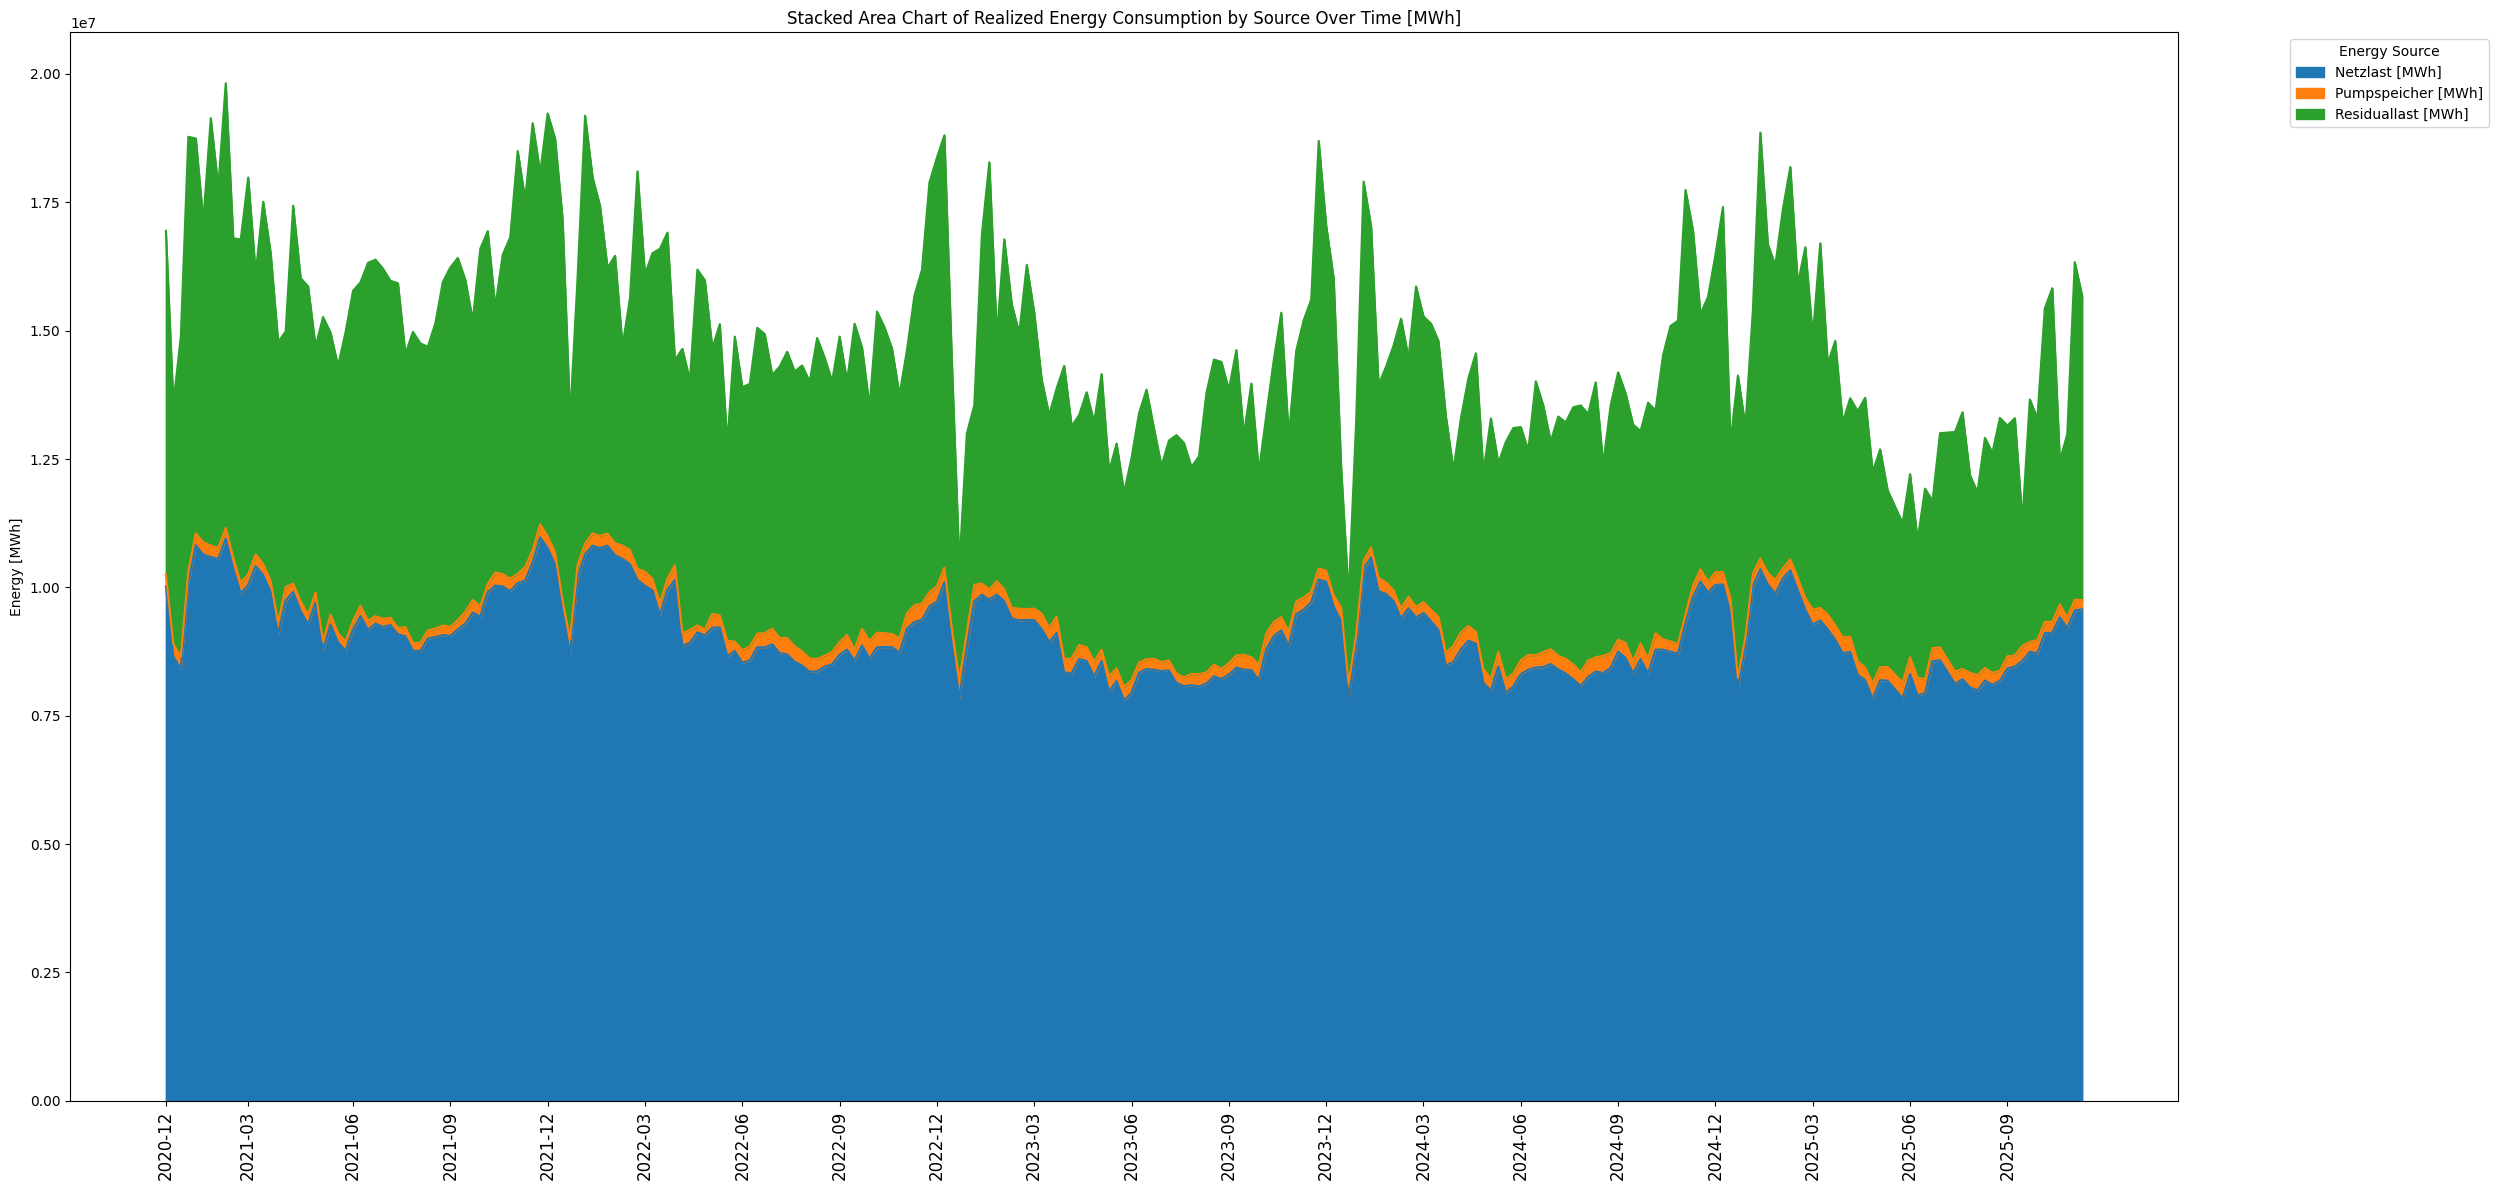

In [13]:
columns_to_stack = ["Netzlast [MWh]", "Pumpspeicher [MWh]", "Residuallast [MWh]"]

fig, ax = plt.subplots(figsize=(25, 12))
df_plot[columns_to_stack].plot(kind='area', stacked=True, ax=ax)

all_month_year_labels = df_plot.index.strftime('%Y-%m')

unique_tick_locations, unique_tick_labels = unique_xticklabels(all_month_year_labels, interval=3)

ax.set_xticks(unique_tick_locations)
ax.set_xticklabels(unique_tick_labels, rotation=90, ha='center', fontsize=12)

ax.set_title('Stacked Area Chart of Realized Energy Consumption by Source Over Time [MWh]')
ax.set_ylabel('Energy [MWh]')
ax.set_xlabel('')
ax.legend(title='Energy Source', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Utilisation

In [14]:
verbrauchPercentDf = verbrauch[["Datum von", "Datum bis", "Gesamtlast [MWh]"]].copy()

for col in verbrauch.columns[3:]:
  verbrauchPercentDf[f"{col}_cons%"] = round(verbrauch[col] / verbrauch['Gesamtlast [MWh]'] * 100, 2)

verbrauchPercentDf = verbrauchPercentDf.rename(columns=lambda x: x.replace(" [MWh]", ""))

verbrauchPercentDf.head()

,Datum von,Datum bis,Gesamtlast,Netzlast_cons%,Netzlast inkl. Pumpspeicher_cons%,Pumpspeicher_cons%,Residuallast_cons%
0,2020-12-14,2020-12-21,16944684.50,59.14,60.52,1.38,39.48
1,2020-12-21,2020-12-28,13571747.75,63.76,65.57,1.81,34.43
2,2020-12-28,2021-01-04,14888680.25,56.47,58.09,1.62,41.91
3,2021-01-04,2021-01-11,18777528.13,53.78,54.89,1.11,45.11
4,2021-01-11,2021-01-18,18743207.50,57.72,58.97,1.25,41.03


In [15]:
verbrauchChangeDf = pd.DataFrame()
verbrauchChangeDf["Datum von"] = verbrauch['Datum von'].copy()
verbrauchChangeDf["Datum bis"] = verbrauch['Datum bis'].copy()

changeCols = [col for col in verbrauch.columns if "[MWh]" in col]

verbrauchChangeDf[changeCols] = round(verbrauch[changeCols].pct_change() * 100, 2)
verbrauchChangeDf = verbrauchChangeDf.fillna(0)
verbrauchChangeDf.head()

,Datum von,Datum bis,Gesamtlast [MWh],Netzlast [MWh],Netzlast inkl. Pumpspeicher [MWh],Pumpspeicher [MWh],Residuallast [MWh]
0,2020-12-14,2020-12-21,0.00,0.00,0.00,0.00,0.00
1,2020-12-21,2020-12-28,-19.91,-13.65,-13.23,4.76,-30.14
2,2020-12-28,2021-01-04,9.70,-2.84,-2.81,-1.89,33.54
3,2021-01-04,2021-01-11,26.12,20.10,19.18,-13.18,35.74
4,2021-01-11,2021-01-18,-0.18,7.13,7.23,11.93,-9.20


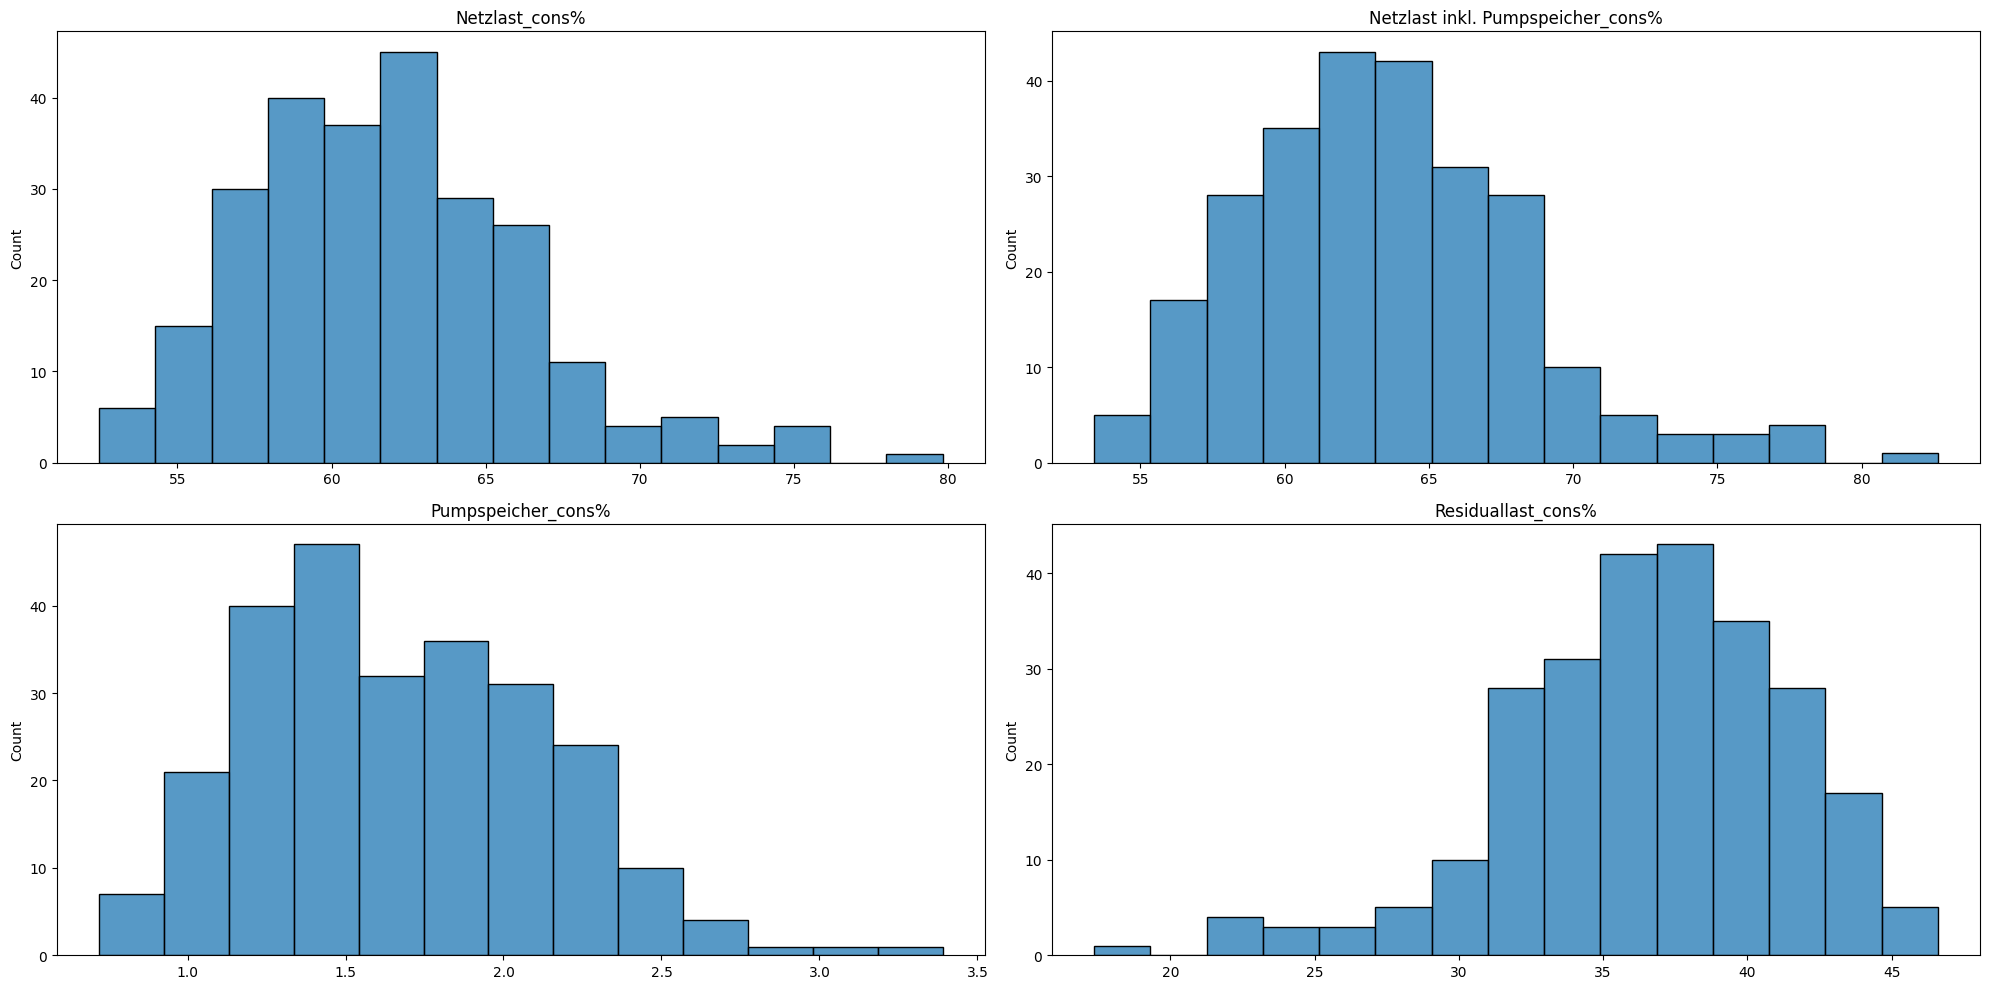

In [16]:
cons_percent_columns = [col for col in verbrauchPercentDf.columns if "cons%" in col]

fig, ax = plt.subplots(2, 2, figsize=(20, 10))
ax = ax.flatten()

for i, col in enumerate(cons_percent_columns):
  sns.histplot(data=verbrauchPercentDf, x=col, ax=ax[i])
  ax[i].set_title(col)
  ax[i].set_xlabel("")

plt.tight_layout()
plt.show()

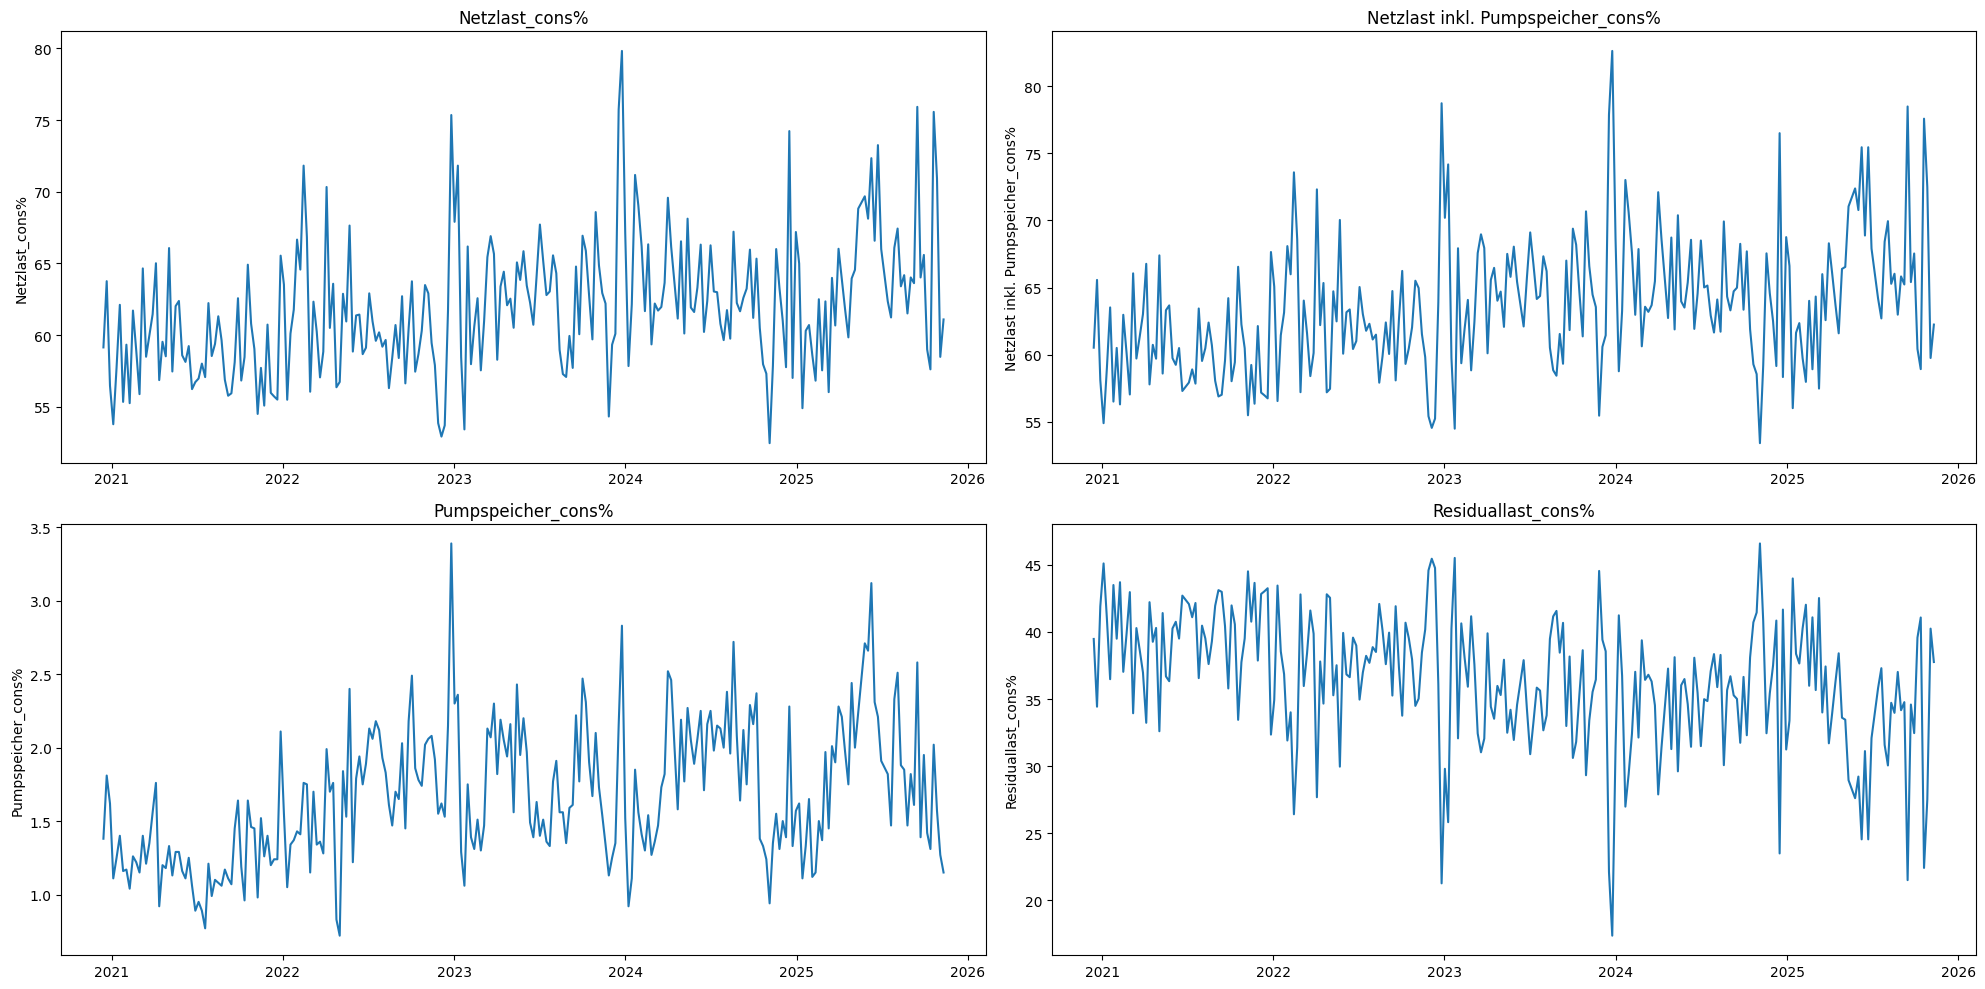

In [17]:
fig, ax = plt.subplots(2, 2, figsize=(20, 10))
ax = ax.flatten()

for i, col in enumerate(cons_percent_columns):
  sns.lineplot(data=verbrauchPercentDf, x="Datum von", y=col, ax=ax[i])
  ax[i].set_title(col)
  ax[i].set_xlabel("")

plt.tight_layout()
plt.show()

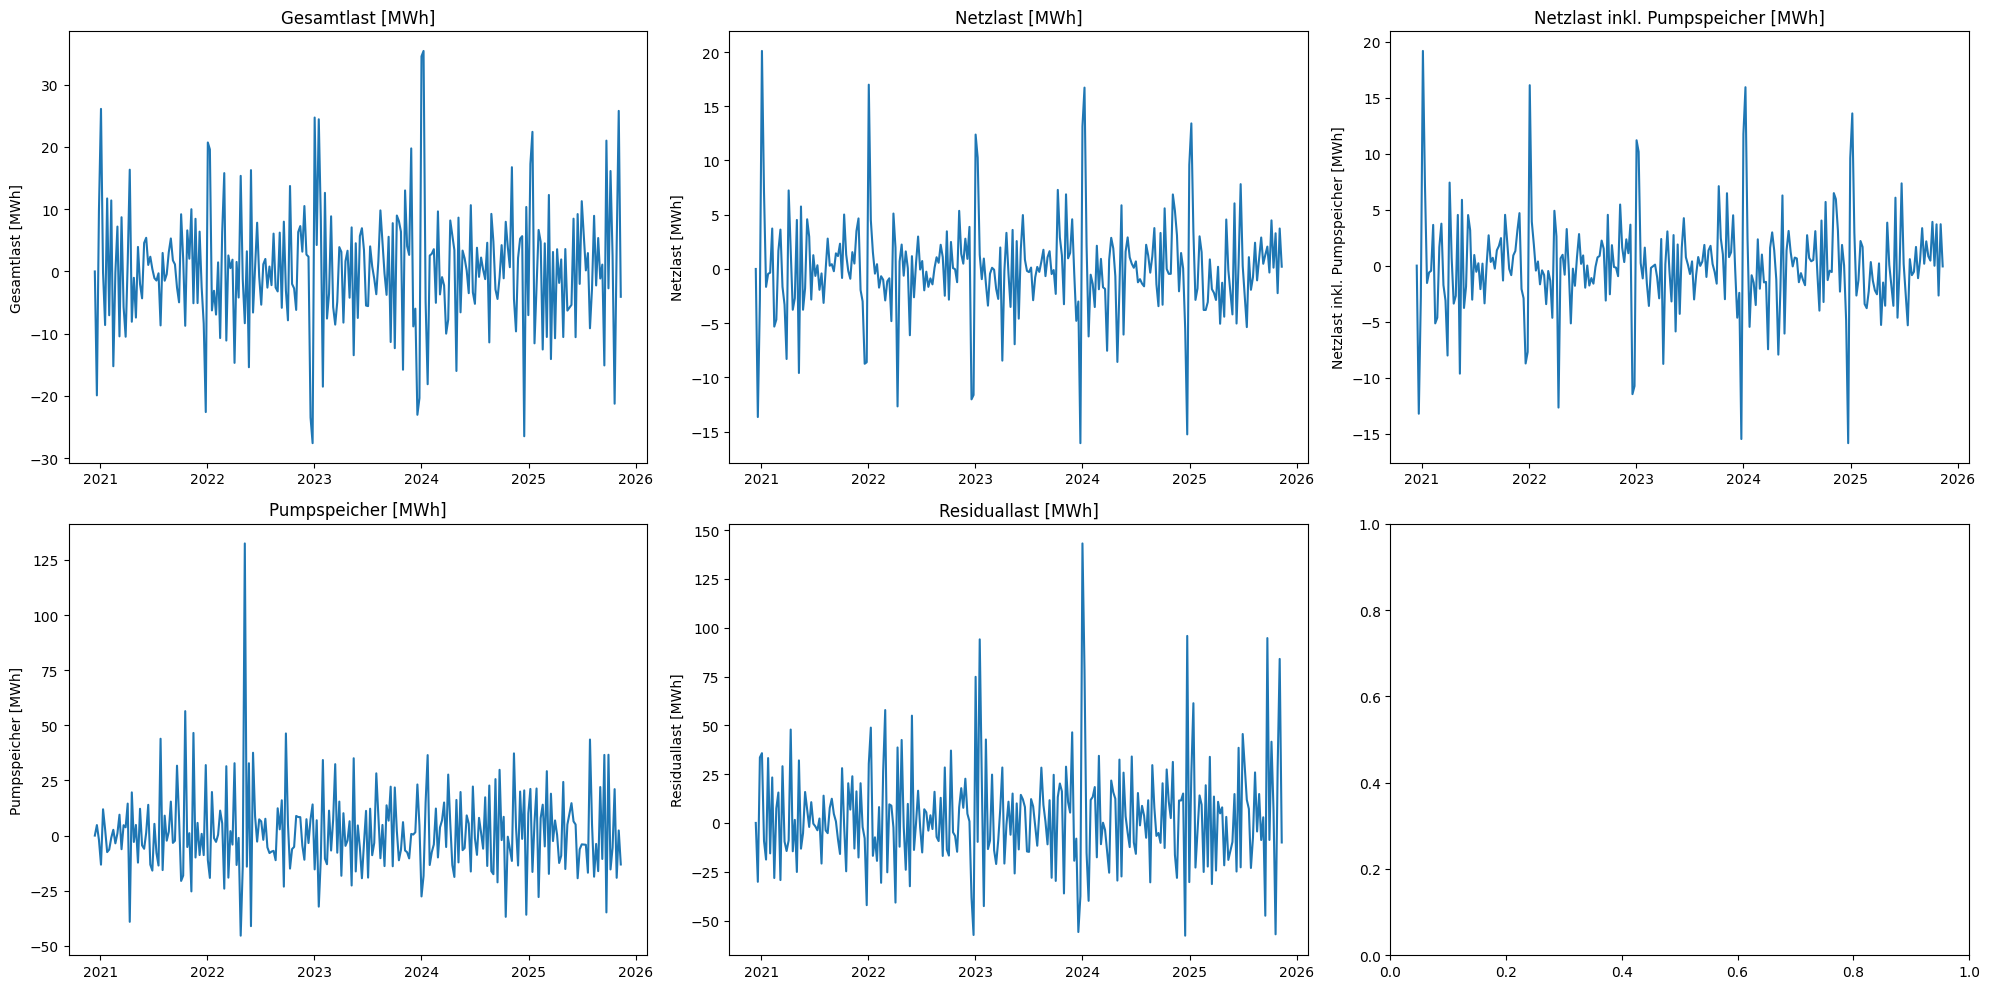

In [18]:
consChangeCols = [col for col in verbrauchChangeDf.columns if "[MWh]" in col]

fig, ax = plt.subplots(2, 3, figsize=(20, 10))
ax = ax.flatten()

for i, col in enumerate(consChangeCols):
  sns.lineplot(data=verbrauchChangeDf, x="Datum von", y=col, ax=ax[i])
  ax[i].set_title(col)
  ax[i].set_xlabel("")

plt.tight_layout()
plt.show()

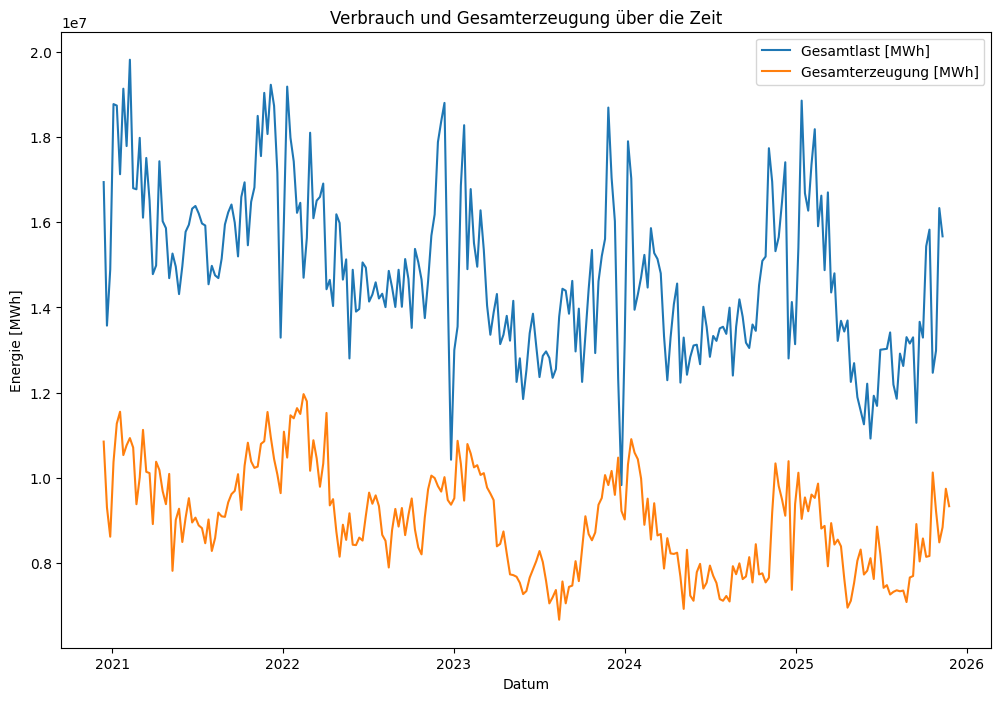

In [20]:
plt.figure(figsize=(12, 8))

sns.lineplot(data=verbrauch, x="Datum von", y="Gesamtlast [MWh]", label="Gesamtlast [MWh]")
sns.lineplot(data=erzeugung, x="Datum von", y="Gesamterzeugung [MWh]", label="Gesamterzeugung [MWh]")

plt.xlabel("Datum")
plt.ylabel("Energie [MWh]")
plt.title("Verbrauch und Gesamterzeugung über die Zeit")
plt.legend(loc='best')

plt.show()

In [21]:
rollingErzeugung = erzeugung['Gesamterzeugung [MWh]'].rolling(window=6, center=True, min_periods=3).mean()
rollingVerbrauch = verbrauch['Gesamtlast [MWh]'].rolling(window=6, center=True, min_periods=3).mean()

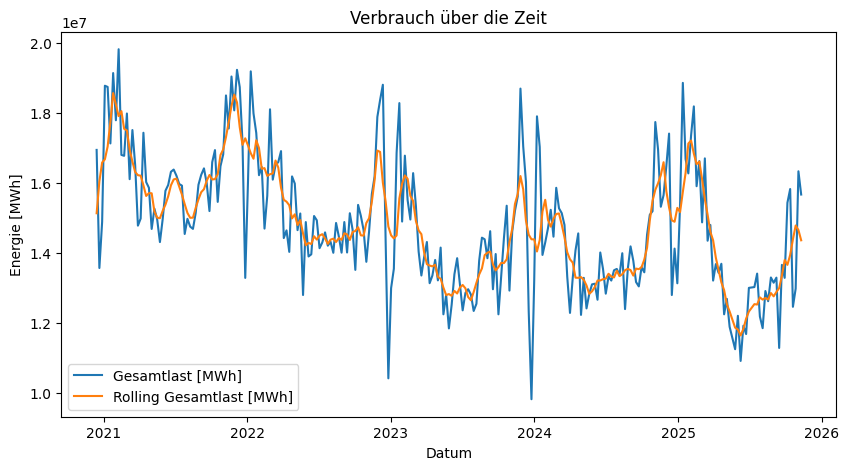

In [22]:
plt.figure(figsize=(10, 5))

sns.lineplot(data=verbrauch, x="Datum von", y="Gesamtlast [MWh]", label="Gesamtlast [MWh]")
sns.lineplot(x=verbrauch['Datum von'], y=rollingVerbrauch, label="Rolling Gesamtlast [MWh]")

plt.xlabel("Datum")
plt.ylabel("Energie [MWh]")
plt.title("Verbrauch über die Zeit")
plt.legend(loc='best')

plt.show()

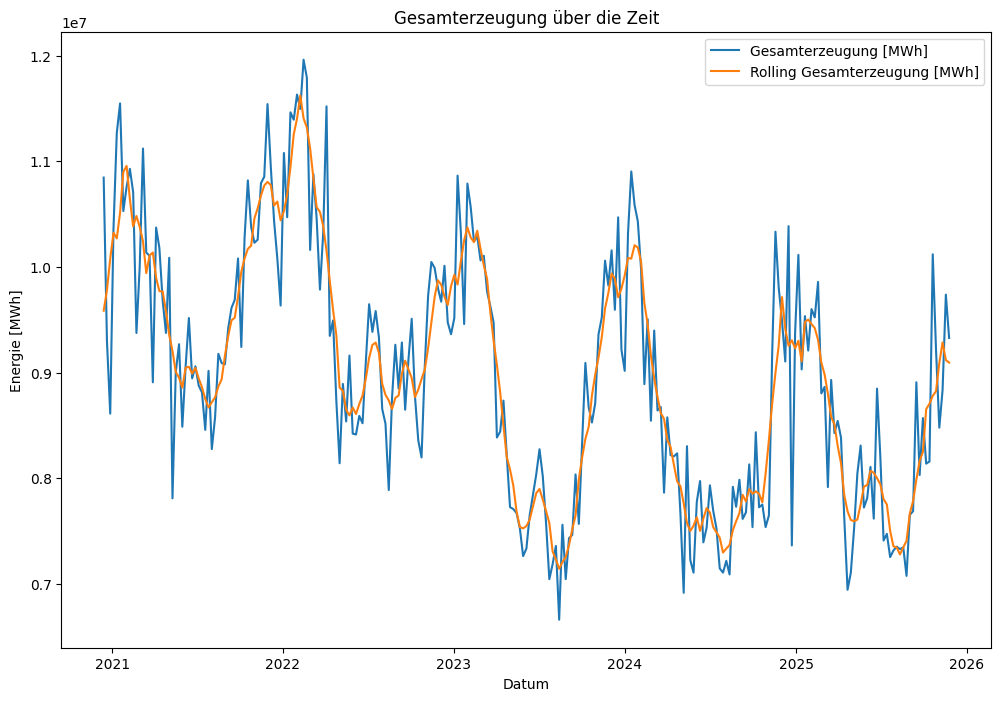

In [23]:
plt.figure(figsize=(12, 8))

sns.lineplot(data=erzeugung, x="Datum von", y="Gesamterzeugung [MWh]", label="Gesamterzeugung [MWh]")
sns.lineplot(x=erzeugung['Datum von'], y=rollingErzeugung, label="Rolling Gesamterzeugung [MWh]")

plt.xlabel("Datum")
plt.ylabel("Energie [MWh]")
plt.title("Gesamterzeugung über die Zeit")
plt.legend(loc='best')

plt.show()

Renewable Share

In [24]:
ee = ["Biomasse [MWh]", "Wasserkraft [MWh]", "Wind Offshore [MWh]", "Wind Onshore [MWh]", "Photovoltaik [MWh]", "Sonstige Erneuerbare [MWh]"]

erzeugung.insert(3, "Gesamt Erneuerbare [MWh]", erzeugung[ee].sum(axis=1))

erzeugung.head()

,Datum von,Datum bis,Gesamterzeugung [MWh],Gesamt Erneuerbare [MWh],Biomasse [MWh],Wasserkraft [MWh],Wind Offshore [MWh],Wind Onshore [MWh],Photovoltaik [MWh],Sonstige Erneuerbare [MWh],Kernenergie [MWh],Braunkohle [MWh],Steinkohle [MWh],Erdgas [MWh],Pumpspeicher [MWh],Sonstige Konventionelle [MWh]
0,2020-12-14,2020-12-21,10846372.75,4375281.50,778769.25,228452.00,840723.00,2282851.75,208337.50,36148.00,1319474.75,2115493.25,969267.25,1602918.75,196815.50,267121.75
1,2020-12-21,2020-12-28,9299571.25,5009163.25,769236.00,225564.50,659089.25,3178818.00,142913.50,33542.00,1295255.75,1097438.75,400630.25,1049778.75,196195.00,251109.50
2,2020-12-28,2021-01-04,8611681.25,3190588.75,772607.00,212520.50,337175.00,1674185.00,156765.25,37336.00,1330677.00,1699151.00,597597.00,1354440.50,167296.75,271930.25
3,2021-01-04,2021-01-11,10367159.25,2654035.75,771324.00,219139.50,483398.50,1066496.00,78002.50,35675.25,1340445.00,2409738.25,1519282.50,1961371.00,205910.75,276376.00
4,2021-01-11,2021-01-18,11269329.25,4141633.50,763837.50,216574.25,588842.25,2420537.75,117714.75,34127.00,1331288.50,2331575.25,1261929.50,1754224.50,182043.75,266634.25


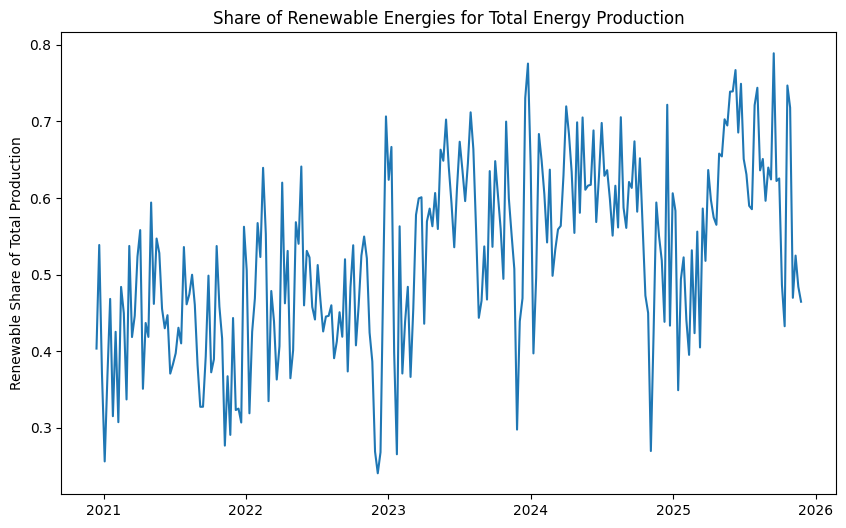

In [25]:
renewableShare = erzeugung.copy()

renewableShare["Renewable Share"] = renewableShare["Gesamt Erneuerbare [MWh]"] / renewableShare["Gesamterzeugung [MWh]"]

plt.figure(figsize=(10, 6))

sns.lineplot(data=renewableShare, x="Datum von", y="Renewable Share")

plt.xlabel("")
plt.ylabel("Renewable Share of Total Production")
plt.title("Share of Renewable Energies for Total Energy Production")

plt.show()